In [24]:
from utils.custom_plots import (line_plot,
                                bar_plot, 
                                scatter_plot,
                                ecdf_plot,
                                box_plot,
                                distribution_plot,
                                grouped_box_plot,
                                pareto_plot)
from utils.db_utils import run_query

import plotly.io as pio
pio.renderers.default = "png"       # drop this two lines to get local interactive plotly charts

<div class="alert alert-block alert-success">

# **Histograms** - overview
- Histogram: Visualizes the frequencies of eachvalue in a dataset

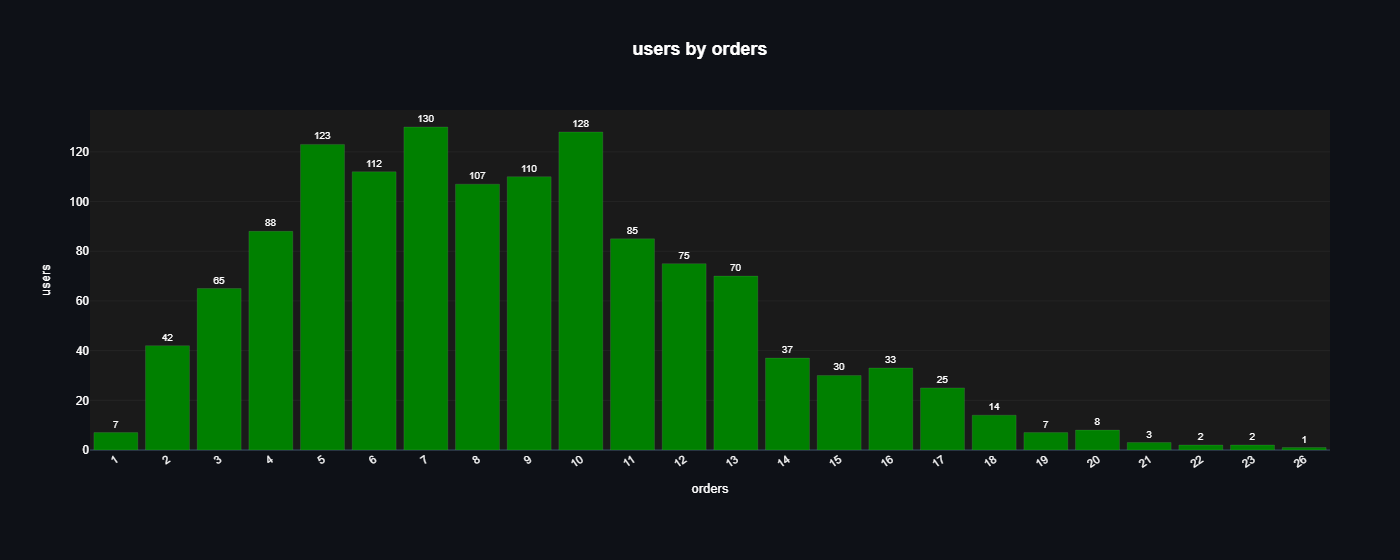

In [6]:
# user's orders histogram query

users_orders_hist_query = run_query('''
WITH user_orders AS (
    SELECT user_id,
           count(DISTINCT order_id) AS orders
    FROM orders
    GROUP BY user_id
)
SELECT count(user_id) AS users,
       orders
FROM user_orders
GROUP BY orders
ORDER BY orders
''')

users_orders_histogram = bar_plot(df=users_orders_hist_query,
                                  x='orders',
                                  y='users',
                                  single_color='green')
users_orders_histogram

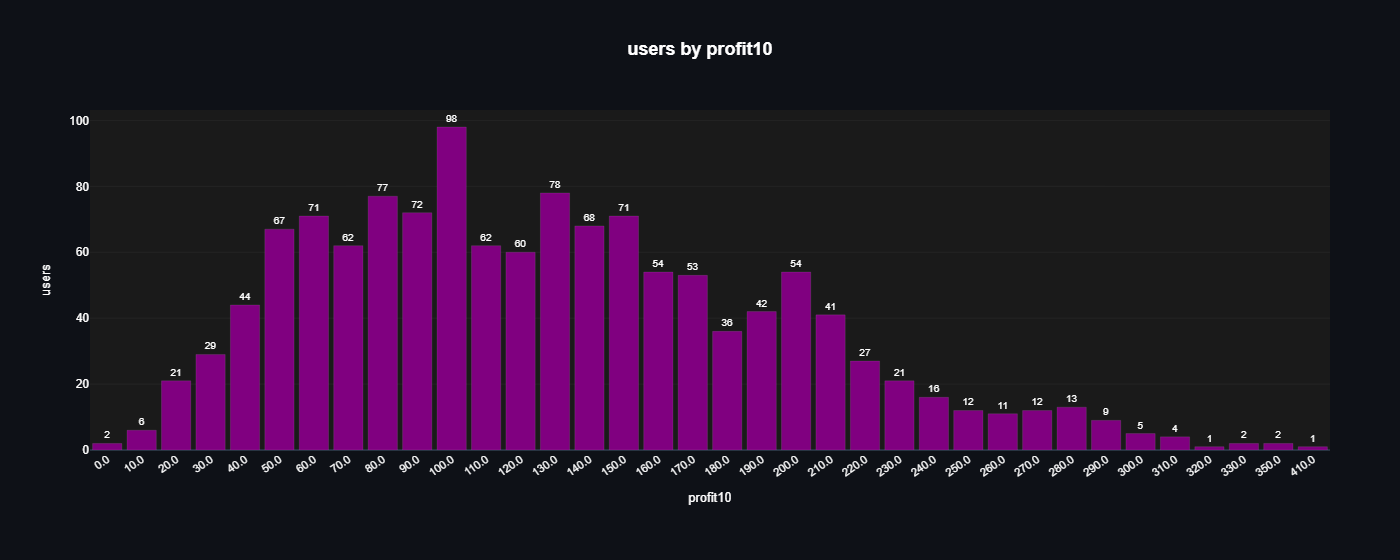

In [17]:
# user's profit histogram query 

users_profit_hist_query = run_query('''
WITH user_profit AS (
    SELECT user_id,
           sum(order_quantity *(meal_price - meal_cost)) AS profit
    FROM orders
        INNER JOIN meals USING (meal_id)
    GROUP BY user_id
)
SELECT round(profit::numeric, -1) as profit10,
       count(user_id) AS users
FROM user_profit
GROUP BY profit10
order by profit10;
''')

users_profit_histogram = bar_plot(df=users_profit_hist_query,
                                  x='profit10',
                                  y='users',
                                  single_color='purple')
users_profit_histogram

<div class="alert alert-block alert-success">

# **Bucketing** - overview
- Using CASE expressions and conditional logic to split data into multiple groups and categories.

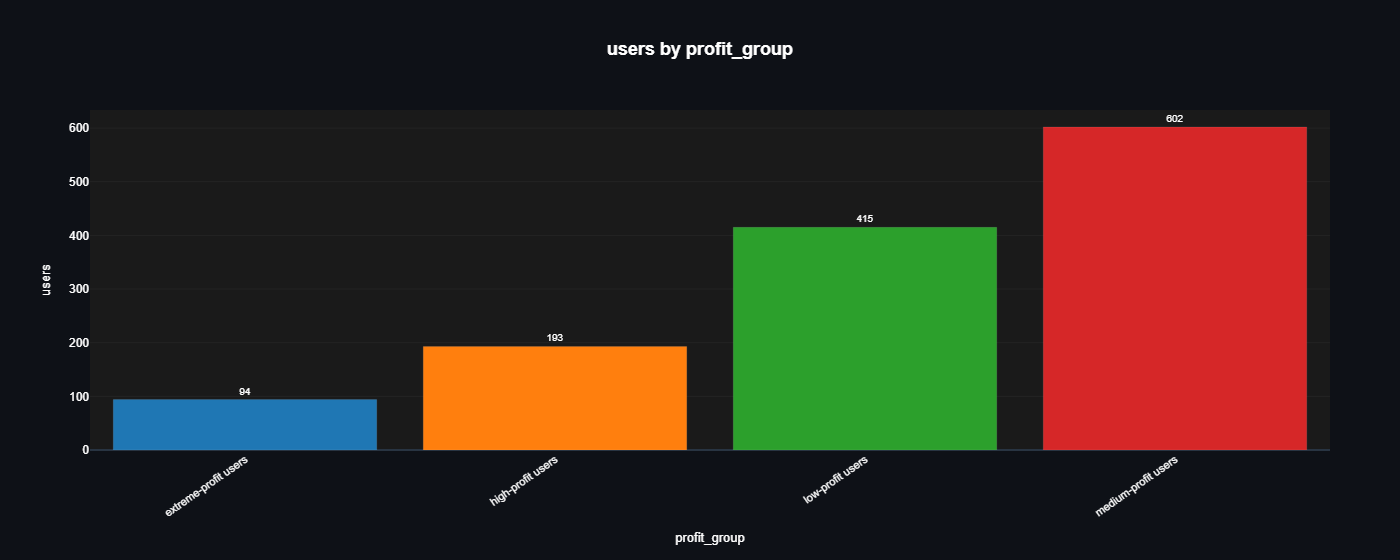

In [20]:
# users profit bucketing query

user_profit_bucketing_query = run_query('''
WITH user_profit AS (
    SELECT user_id,
           sum(order_quantity *(meal_price - meal_cost)) AS profit
    FROM orders
        INNER JOIN meals USING (meal_id)
    GROUP BY user_id
)
SELECT CASE WHEN profit < 90 THEN
        'low-profit users'
    WHEN profit < 180 THEN
        'medium-profit users'
    WHEN profit < 230 THEN
        'high-profit users'
    ELSE
        'extreme-profit users'
    END               AS profit_group,
       count(user_id) AS users
FROM user_profit
GROUP BY profit_group
ORDER BY users;
''')

user_profit_bucketing_barplot = bar_plot(df=user_profit_bucketing_query,
                                         x='profit_group',
                                         y='users'
                                         )
user_profit_bucketing_barplot

<div class="alert alert-block alert-success">

# **Percentiles** - overview
- Percentile: nth percentile is the value for which n% of a dataset's values are beneath this value
    - Lowest value is the 0th percentile
    - Highest value is the 99th percentile

<div class="alert alert-block alert-success">

## **Quartiles**
- **Example**: 25th percentile of user orders is 17, then 25% have ordered 17 times or less
- **First quartile**: 25th percentile
- **Third quartile**: 75th percentile
- **Interquartile range (IQR)**: All data between the first and third quartiles
- **Second quartile**: 50th percentile, median
    - Different from the mean

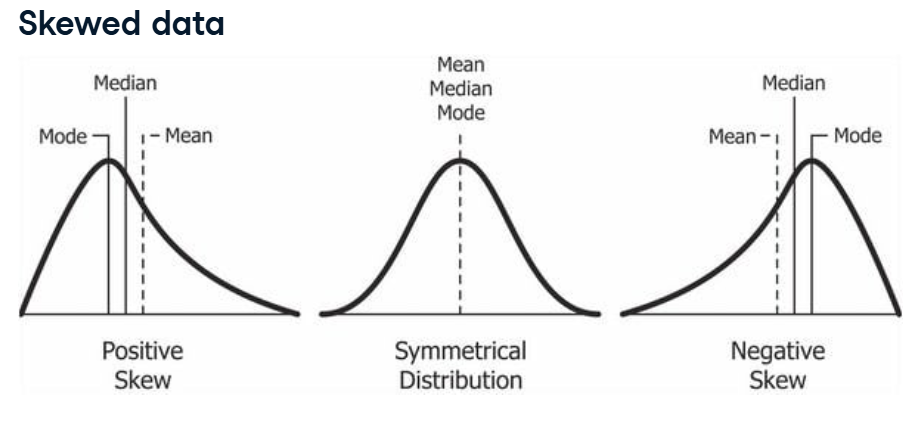

In [ ]:
# profit quartiles query 

profit_quartiles_query = run_query('''
WITH user_profit AS (
    SELECT user_id,
           sum(order_quantity *(meal_price - meal_cost)) AS profit
    FROM orders
        INNER JOIN meals USING (meal_id)
    GROUP BY user_id
)
SELECT round(percentile_cont(0.25) WITHIN GROUP (ORDER BY profit)::numeric, 2) AS profit_q1,
       round(percentile_cont(0.5) WITHIN GROUP (ORDER BY profit)::numeric, 2)  AS profit_q2,
       round(percentile_cont(0.75) WITHIN GROUP (ORDER BY profit)::numeric, 2) AS profit_q3,
       round(avg(profit)::numeric, 2)                                          AS profit_avg
FROM user_profit
''')

profit_quartiles_query

,profit_q1,profit_q2,profit_q3,profit_avg
0,78.0,122.0,172.13,128.91


### profit_q2 is slightly lower than profit_avg so data is slightly positively skewed.
#### meaning that number of users with lower profit generation is higher than users with higher profit generation. 
#### or we can say that small amount of users with extreme profit generation made the data positively skewed.

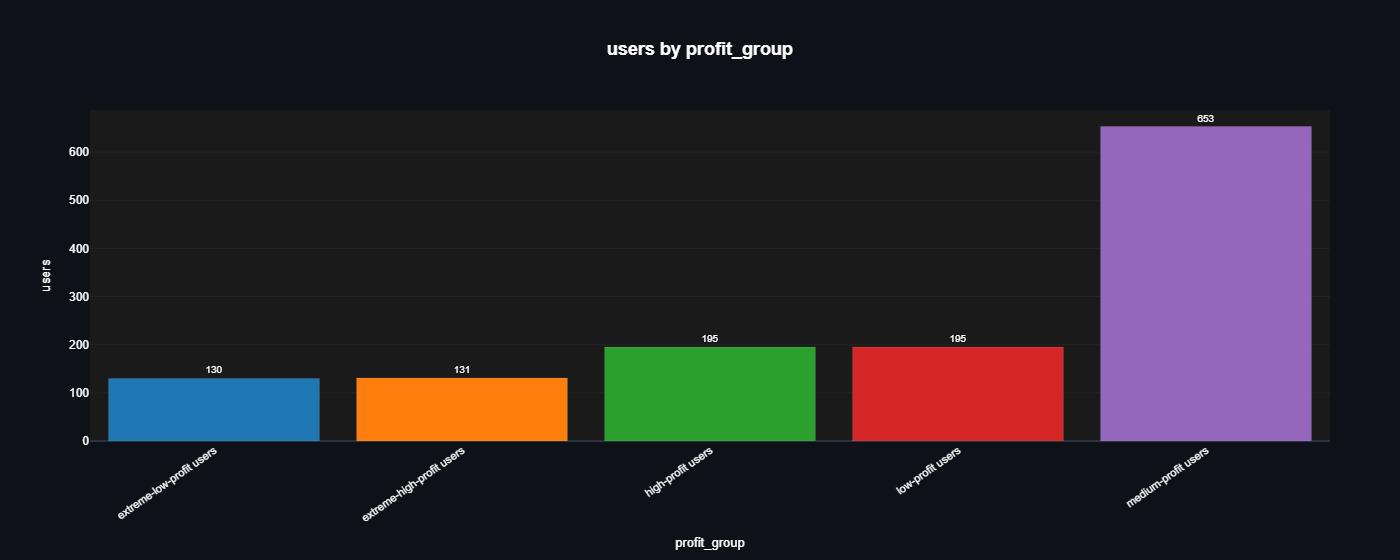

In [23]:
# bucketing data using percentiles:

profit_percentile_bucketing_query = run_query('''
WITH user_profit AS (
    SELECT user_id,
           sum(order_quantity *(meal_price - meal_cost)) AS profit
    FROM orders
        INNER JOIN meals USING (meal_id)
    GROUP BY user_id
),
user_profit_percentiles AS (
    SELECT percentile_cont(0.10) WITHIN GROUP (ORDER BY profit) AS p10,
           percentile_cont(0.25) WITHIN GROUP (ORDER BY profit) AS p25,
           percentile_cont(0.75) WITHIN GROUP (ORDER BY profit) AS p75,
           percentile_cont(0.90) WITHIN GROUP (ORDER BY profit) AS p90
    FROM user_profit
)
SELECT CASE WHEN profit < p10 THEN
        'extreme-low-profit users'
    WHEN profit < p25 THEN
        'low-profit users'
    WHEN profit < p75 THEN
        'medium-profit users'
    WHEN profit < p90 THEN
        'high-profit users'
    ELSE
        'extreme-high-profit users'
    END               AS profit_group,
       count(user_id) AS users
FROM user_profit
cross join user_profit_percentiles
GROUP BY profit_group
ORDER BY users;
''')

profit_percentile_bucketing_barplot = bar_plot(df=profit_percentile_bucketing_query,
                                               x='profit_group',
                                               y='users')
profit_percentile_bucketing_barplot

<div class="alert alert-block alert-success">

# **Pareto Analysis** - overview
- seeing how many top entities did x percent of the job
    - for example seeing how many top users generated 80 percent of the profit   

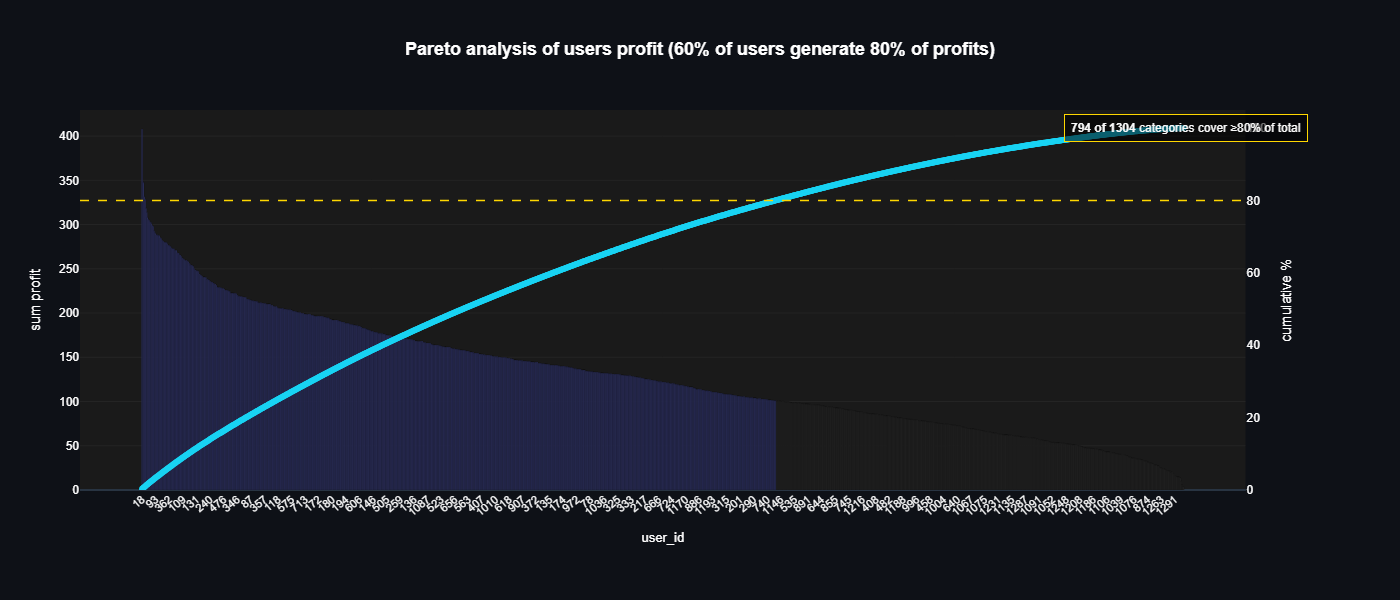

In [29]:
# users profit pareto analysis query

users_profit_query = run_query('''
SELECT user_id,
       sum(order_quantity *(meal_price - meal_cost)) AS profit
FROM orders
    INNER JOIN meals USING (meal_id)
GROUP BY user_id
''')

users_profit_paretoplot = pareto_plot(df=users_profit_query,
                                      category_col='user_id',
                                      value_col='profit',
                                      title='Pareto analysis of users profit (60% of users generate 80% of profits)',
                                      cutoff=0.8
                                      )
users_profit_paretoplot

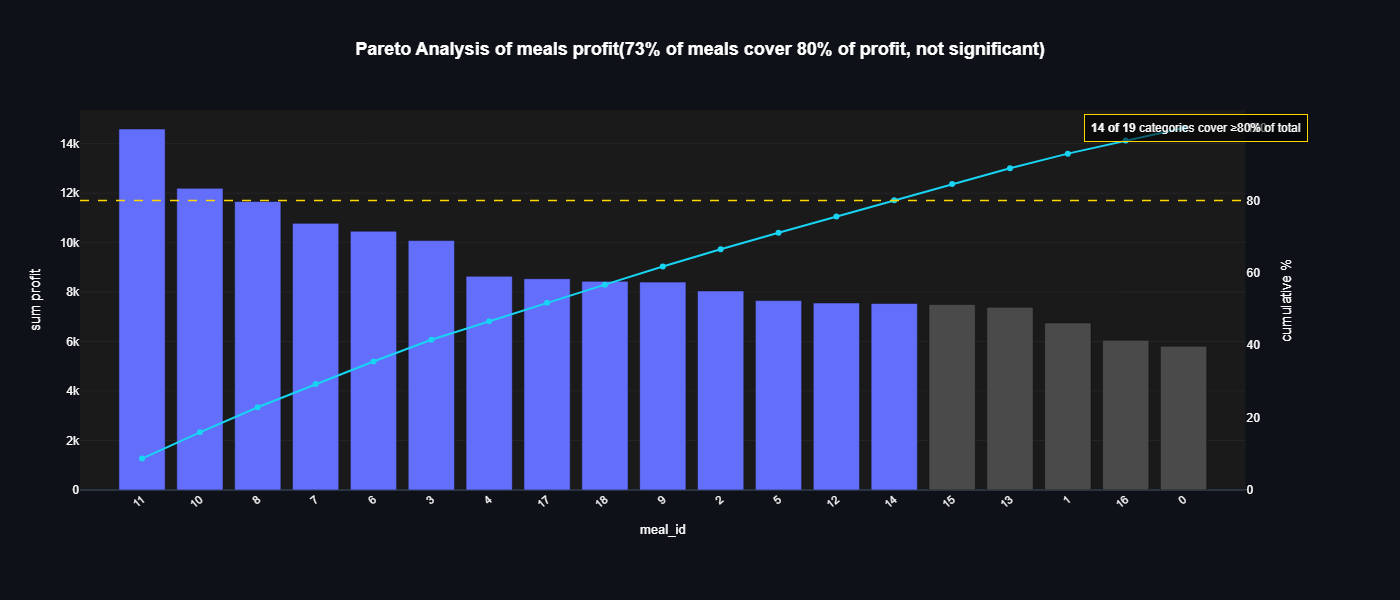

In [31]:
# meal profit pareto analysis query

meal_profit_query = run_query('''
SELECT meal_id,
       sum(order_quantity *(meal_price - meal_cost)) AS profit
FROM orders
    INNER JOIN meals USING (meal_id)
GROUP BY meal_id;
''')

meal_profit_paretoplot = pareto_plot(df=meal_profit_query,
                                     category_col='meal_id',
                                     value_col='profit',
                                     cutoff=0.8,
                                     title='Pareto Analysis of meals profit(73% of meals cover 80% of profit, not significant)')
meal_profit_paretoplot

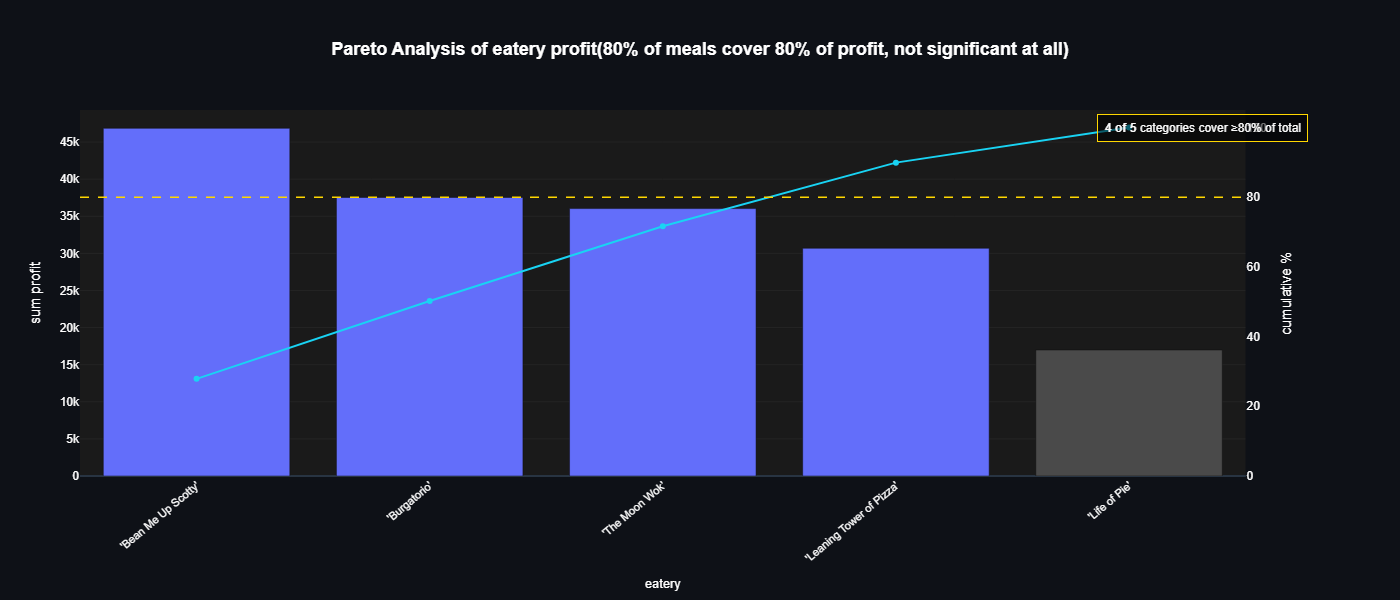

In [33]:
# eatery profit pareto analysis query

eatery_profit_query = run_query('''
SELECT eatery,
       sum(order_quantity *(meal_price - meal_cost)) AS profit
FROM orders
    INNER JOIN meals USING (meal_id)
GROUP BY eatery;
''')

eatery_profit_paretoplot = pareto_plot(df=eatery_profit_query,
                                     category_col='eatery',
                                     value_col='profit',
                                     cutoff=0.8,
                                     title='Pareto Analysis of eatery profit(80% of meals cover 80% of profit, not significant at all)')
eatery_profit_paretoplot

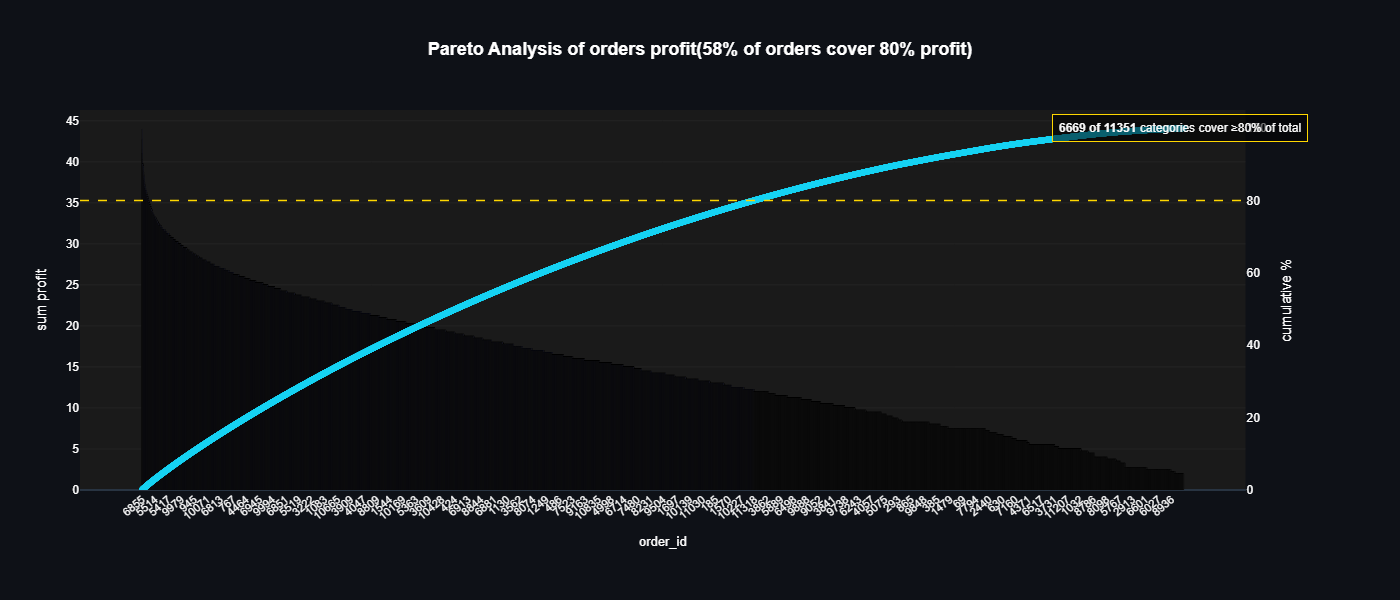

In [36]:
# orders profit pareto analysis query

orders_profit_query = run_query('''
SELECT order_id,
       sum(order_quantity *(meal_price - meal_cost)) AS profit
FROM orders
    INNER JOIN meals USING (meal_id)
GROUP BY order_id;
''')

orders_profit_paretoplot = pareto_plot(df=orders_profit_query,
                                       category_col='order_id',
                                       value_col='profit',
                                       title='Pareto Analysis of orders profit(58% of orders cover 80% profit)')
orders_profit_paretoplot